# Ejercicio 5 - Incorporacion incremental de datos de 2024

Este cuaderno valida la descarga de Yellow y Green Taxi de 2024, prepara los nuevos Parquet procesados y demuestra que DuckDB puede consultar conjuntamente 2024 y 2026. El descargador original de 2026 permanece sin cambios; para 2024 se utiliza `scripts/download_data_ejercicio_5.py`.

## Procedimiento

Desde la raiz del repositorio:

```bash
python scripts/download_data.py
python scripts/download_data_ejercicio_5.py
```

El segundo comando escribe exclusivamente en `data/raw/<tipo>/2024/`. Si un archivo local no vacio ya existe, lo omite, por lo que conserva y no vuelve a descargar los datos de 2026.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
os.chdir(ROOT / 'notebooks')
con = duckdb.connect()

def read_sql(name):
    return (ROOT / 'sql' / name).read_text(encoding='utf-8').strip().rstrip(';')

def run_sql(number):
    return con.execute(read_sql(f'ejercicio_5_{number}.sql')).df()

print('Ambiente listo:', ROOT)

Ambiente listo: C:\Users\marti\OneDrive\Documentos\uni\s8\data science\labs\duckdb


## 5.4 y 5.5 Verificacion de archivos descargados

Para 2024 se esperan doce meses completos por cada tipo. La validacion revisa nombres, cantidad y tamaño mayor que cero. Para 2026 se conserva la cantidad disponible al momento de la ejecucion, porque la TLC publica los meses progresivamente.

In [2]:
inventory_rows = []
for year in (2024, 2026):
    for taxi in ('yellow', 'green'):
        folder = ROOT / 'data' / 'raw' / taxi / str(year)
        files = sorted(folder.glob(f'{taxi}_tripdata_{year}-??.parquet'))
        inventory_rows.append({
            'data_year': year,
            'taxi_type': taxi,
            'files': len(files),
            'size_mib': round(sum(path.stat().st_size for path in files) / 1024**2, 2),
            'empty_files': sum(path.stat().st_size == 0 for path in files),
        })

file_inventory = pd.DataFrame(inventory_rows)
display(file_inventory)

assert (file_inventory.query('data_year == 2024')['files'] == 12).all(), 'Faltan meses de 2024'
assert (file_inventory['empty_files'] == 0).all(), 'Se encontraron archivos vacios'
print('Validacion correcta: 24 archivos de 2024 y ningun archivo vacio.')

,data_year,taxi_type,files,size_mib,empty_files
0,2024,yellow,12,660.90,0
1,2024,green,12,15.18,0
2,2026,yellow,8,487.76,0
3,2026,green,8,7.89,0


Validacion correcta: 24 archivos de 2024 y ningun archivo vacio.


### Consulta de inventario y filas raw

**Consulta:** `sql/ejercicio_5_2.sql`  
**Objetivo:** comprobar con DuckDB la cantidad de archivos y filas de cada combinacion de año y tipo.  
**Fuentes:** los cuatro directorios raw de 2024 y 2026.  
**Decision:** 2024 debe contener doce archivos por tipo; 2026 se interpreta como un conjunto incremental.

In [3]:
raw_inventory = run_sql(2)
display(raw_inventory)

,data_year,taxi_type,files,raw_rows
0,2024,green,12,660218
1,2024,yellow,12,41169720
2,2026,green,8,337114
3,2026,yellow,8,29703355


## Preparacion de datos de 2024

Las consultas `sql/ejercicio_5_1_y.sql` y `sql/ejercicio_5_1_g.sql` son copias adaptadas de la limpieza del ejercicio 3. En 2024 no existe `cbd_congestion_fee`, por lo que se agrega como `NULL::DOUBLE` para mantener compatibilidad con 2026. DuckDB escribe los resultados directamente a Parquet sin materializar todas las filas en pandas.

In [4]:
for taxi in ('yellow', 'green'):
    output = ROOT / 'data' / 'processed' / f'{taxi}_2024.parquet'
    output.unlink(missing_ok=True)
    query = read_sql(f'ejercicio_5_1_{taxi[0]}.sql')
    output_sql = output.as_posix().replace("'", "''")
    con.execute(f"COPY ({query}) TO '{output_sql}' (FORMAT PARQUET, COMPRESSION ZSTD)")
    print(f'Generado {output.relative_to(ROOT)} ({output.stat().st_size / 1024**2:.1f} MiB)')

Generado data\processed\yellow_2024.parquet (589.4 MiB)


Generado data\processed\green_2024.parquet (10.4 MiB)


## 5.6 Consulta conjunta de 2024 y 2026

**Consulta:** `sql/ejercicio_5_3.sql`  
**Objetivo:** demostrar una consulta unica sobre los cuatro Parquet procesados y comparar volumen, distancia y monto por mes.  
**Fuentes:** `yellow_2024.parquet`, `green_2024.parquet`, `yellow_2026.parquet` y `green_2026.parquet`.  
**Decision:** seleccionar columnas comunes explicitamente, agregar `data_year` y excluir fechas que no correspondan al año nominal del archivo.

,data_year,month,taxi_type,trips,avg_distance,avg_total_amount
0,2024,1,green,56370,31.59,22.51
1,2024,1,yellow,2929057,3.66,27.43
2,2024,2,green,53403,17.72,22.75
3,2024,2,yellow,2971447,3.87,27.26
4,2024,3,green,57254,13.57,23.02
5,2024,3,yellow,3538183,4.53,27.79
6,2024,4,green,56257,12.13,23.51
7,2024,4,yellow,3470476,5.31,28.18
8,2024,5,green,60781,14.66,24.71
9,2024,5,yellow,3674808,5.39,29.12


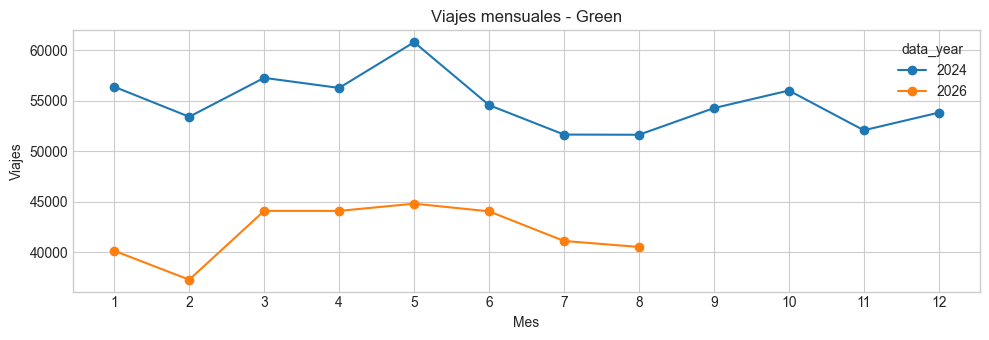

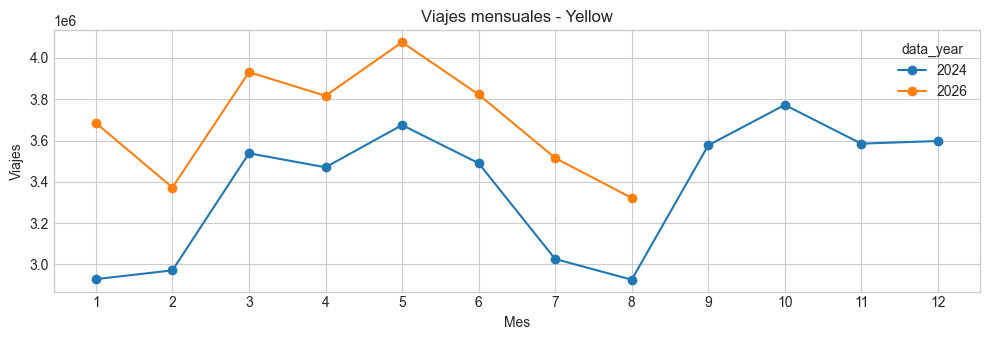

Consulta conjunta correcta. Años encontrados: [2024, 2026]


In [5]:
combined = run_sql(3)
display(combined)

for taxi, group in combined.groupby('taxi_type'):
    plot_data = group.pivot(index='month', columns='data_year', values='trips')
    ax = plot_data.plot(figsize=(10, 3.5), marker='o')
    ax.set(title=f'Viajes mensuales - {taxi.title()}', xlabel='Mes', ylabel='Viajes')
    ax.set_xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

years = sorted(combined['data_year'].unique().tolist())
assert years == [2024, 2026], f'Años inesperados: {years}'
print('Consulta conjunta correcta. Años encontrados:', years)

### Control de fechas por año

**Consulta:** `sql/ejercicio_5_4.sql`  
**Objetivo:** contar filas procesadas y fechas de recogida fuera del año indicado por el archivo.  
**Fuentes:** los cuatro Parquet procesados.  
**Decision:** conservar esas filas como evidencia de calidad, pero excluirlas de comparaciones temporales.

In [6]:
year_quality = run_sql(4)
display(year_quality)
print('Fechas fuera del año esperado:', int(year_quality['pickup_outside_expected_year'].sum()))

,data_year,taxi_type,processed_rows,pickup_outside_expected_year
0,2024,green,658042,19
1,2024,yellow,40558815,55
2,2026,green,336086,14
3,2026,yellow,29541512,16


Fechas fuera del año esperado: 104


## 5.7 Cambios requeridos en las consultas anteriores

| Consulta anterior | ¿Cambia? | Cambio necesario |
|---|---:|---|
| Exploracion del ejercicio 3 | Si | Sus rutas apuntan directamente a `raw/<tipo>/2026`; para explorar 2024 se usa una copia con la ruta del nuevo año. |
| Limpieza del ejercicio 3 | Si | Ademas de cambiar la ruta, 2024 necesita crear `cbd_congestion_fee` como nulo tipado porque esa columna aun no existia. |
| Agregaciones del ejercicio 4 | Parcial | La logica de agregacion se conserva, pero la fuente debe unir los Parquet requeridos y agregar `data_year`. |
| Comparacion Yellow/Green | No en su estructura | Se siguen seleccionando columnas comunes explicitamente; no se debe usar `SELECT *` porque Yellow y Green tienen columnas finales diferentes. |
| Filtros temporales | Si | Deben derivarse de `data_year` o declararse por cada fuente para evitar incluir fechas anomalas fuera del periodo. |

Por lo tanto, las preguntas y agregaciones siguen siendo validas, pero las fuentes codificadas para 2026 no incorporan automaticamente 2024.

## 5.9 Diseño incremental

El flujo incorpora nuevos archivos con cambios acotados porque:

- separa datos por `tipo/año`, evitando sobrescribir periodos existentes;
- los descargadores son idempotentes y omiten archivos locales no vacios;
- las transformaciones se expresan en SQL versionado y escriben Parquet derivados;
- las consultas conjuntas usan `UNION ALL`, columnas explicitas y una etiqueta `data_year`;
- los datos descargados y procesados estan excluidos de Git, pero el codigo para regenerarlos esta versionado;
- DuckDB consulta varios Parquet sin importarlos previamente a un servidor.

La unica adaptacion de esquema necesaria en 2024 fue representar `cbd_congestion_fee` como nulo tipado. Esta normalizacion permite que el resto del analisis trabaje con una interfaz estable.

## Conclusion

La incorporacion de 2024 conserva los datos de 2026 y permite analizarlos conjuntamente desde DuckDB. La organizacion particionada, la descarga idempotente y la normalizacion explicita del esquema reducen los cambios necesarios, aunque las consultas que tenian rutas o años fijos deben actualizar su fuente.